## PRCP-1008-NBAShotSelection

### TABLE OF CONTENTS
1. Understanding the Objective
2. Importing Required Libraries
3. Loading the Dataset and EDA
4. Using Semi-Supervised Model
5. Scaling & Feature Engineering
6. Model Development
7. Conclusion and Insights

### 1. Objective
    Building a model to predict whether the player will score or not score, based on the given features.

### 2. Importing Necessaary Libraries

In [26]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#Importing the Data Set

nba = pd.read_csv(r"C:\Users\Admin\Desktop\Data_Science\Internship\Data Sets\Data - NBA\data.csv")
nba

,action_type,combined_shot_type,game_event_id,game_id,lat,loc_x,loc_y,lon,minutes_remaining,period,...,shot_type,shot_zone_area,shot_zone_basic,shot_zone_range,team_id,team_name,game_date,matchup,opponent,shot_id
0,Jump Shot,Jump Shot,10,20000012,33.9723,167,72,-118.1028,10,1,...,2PT Field Goal,Right Side(R),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,10/31/2000,LAL @ POR,POR,1
1,Jump Shot,Jump Shot,12,20000012,34.0443,-157,0,-118.4268,10,1,...,2PT Field Goal,Left Side(L),Mid-Range,8-16 ft.,1610612747,Los Angeles Lakers,10/31/2000,LAL @ POR,POR,2
2,Jump Shot,Jump Shot,35,20000012,33.9093,-101,135,-118.3708,7,1,...,2PT Field Goal,Left Side Center(LC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,10/31/2000,LAL @ POR,POR,3
3,Jump Shot,Jump Shot,43,20000012,33.8693,138,175,-118.1318,6,1,...,2PT Field Goal,Right Side Center(RC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,10/31/2000,LAL @ POR,POR,4
4,Driving Dunk Shot,Dunk,155,20000012,34.0443,0,0,-118.2698,6,2,...,2PT Field Goal,Center(C),Restricted Area,Less Than 8 ft.,1610612747,Los Angeles Lakers,10/31/2000,LAL @ POR,POR,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30692,Jump Shot,Jump Shot,397,49900088,33.9963,1,48,-118.2688,6,4,...,2PT Field Goal,Center(C),In The Paint (Non-RA),Less Than 8 ft.,1610612747,Los Angeles Lakers,6/19/2000,LAL vs. IND,IND,30693
30693,Tip Shot,Tip Shot,398,49900088,34.0443,0,0,-118.2698,6,4,...,2PT Field Goal,Center(C),Restricted Area,Less Than 8 ft.,1610612747,Los Angeles Lakers,6/19/2000,LAL vs. IND,IND,30694
30694,Running Jump Shot,Jump Shot,426,49900088,33.8783,-134,166,-118.4038,3,4,...,2PT Field Goal,Left Side Center(LC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,6/19/2000,LAL vs. IND,IND,30695
30695,Jump Shot,Jump Shot,448,49900088,33.7773,31,267,-118.2388,2,4,...,3PT Field Goal,Center(C),Above the Break 3,24+ ft.,1610612747,Los Angeles Lakers,6/19/2000,LAL vs. IND,IND,30696


### Exploratory Data Analysis:
Duplicate Check: Verify the dataset for any duplicate entries to prevent redundant data. If duplicates are found, they should be removed to enhance the model’s performance.

Null Value Check: Inspect the dataset for missing values to avoid bias. If null values are present, they should be appropriately imputed or replaced based on the nature of the data.

Data Type Verification: Examine the data types of all features. If any non-numerical features exist, they must be encoded into numerical format before model training.

Statistical Summary: Perform an overall statistical analysis to understand metrics such as mean, median, standard deviation, and maximum values. This helps in effective feature engineering.

Visualization: Create visualizations to analyze features and gain better insights into their relationships.

In [2]:
nba.head()

,action_type,combined_shot_type,game_event_id,game_id,lat,loc_x,loc_y,lon,minutes_remaining,period,...,shot_type,shot_zone_area,shot_zone_basic,shot_zone_range,team_id,team_name,game_date,matchup,opponent,shot_id
0,Jump Shot,Jump Shot,10,20000012,33.9723,167,72,-118.1028,10,1,...,2PT Field Goal,Right Side(R),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,10/31/2000,LAL @ POR,POR,1
1,Jump Shot,Jump Shot,12,20000012,34.0443,-157,0,-118.4268,10,1,...,2PT Field Goal,Left Side(L),Mid-Range,8-16 ft.,1610612747,Los Angeles Lakers,10/31/2000,LAL @ POR,POR,2
2,Jump Shot,Jump Shot,35,20000012,33.9093,-101,135,-118.3708,7,1,...,2PT Field Goal,Left Side Center(LC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,10/31/2000,LAL @ POR,POR,3
3,Jump Shot,Jump Shot,43,20000012,33.8693,138,175,-118.1318,6,1,...,2PT Field Goal,Right Side Center(RC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,10/31/2000,LAL @ POR,POR,4
4,Driving Dunk Shot,Dunk,155,20000012,34.0443,0,0,-118.2698,6,2,...,2PT Field Goal,Center(C),Restricted Area,Less Than 8 ft.,1610612747,Los Angeles Lakers,10/31/2000,LAL @ POR,POR,5


In [3]:
nba.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30697 entries, 0 to 30696
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   action_type         30697 non-null  object 
 1   combined_shot_type  30697 non-null  object 
 2   game_event_id       30697 non-null  int64  
 3   game_id             30697 non-null  int64  
 4   lat                 30697 non-null  float64
 5   loc_x               30697 non-null  int64  
 6   loc_y               30697 non-null  int64  
 7   lon                 30697 non-null  float64
 8   minutes_remaining   30697 non-null  int64  
 9   period              30697 non-null  int64  
 10  playoffs            30697 non-null  int64  
 11  season              30697 non-null  object 
 12  seconds_remaining   30697 non-null  int64  
 13  shot_distance       30697 non-null  int64  
 14  shot_made_flag      25697 non-null  float64
 15  shot_type           30697 non-null  object 
 16  shot

In [4]:
nba.columns

Index(['action_type', 'combined_shot_type', 'game_event_id', 'game_id', 'lat',
       'loc_x', 'loc_y', 'lon', 'minutes_remaining', 'period', 'playoffs',
       'season', 'seconds_remaining', 'shot_distance', 'shot_made_flag',
       'shot_type', 'shot_zone_area', 'shot_zone_basic', 'shot_zone_range',
       'team_id', 'team_name', 'game_date', 'matchup', 'opponent', 'shot_id'],
      dtype='object')

In [5]:
nba.describe()

,game_event_id,game_id,lat,loc_x,loc_y,lon,minutes_remaining,period,playoffs,seconds_remaining,shot_distance,shot_made_flag,team_id,shot_id
count,30697.000000,3.069700e+04,30697.000000,30697.000000,30697.000000,30697.000000,30697.000000,30697.000000,30697.000000,30697.000000,30697.000000,25697.000000,3.069700e+04,30697.000000
mean,249.190800,2.476407e+07,33.953192,7.110499,91.107535,-118.262690,4.885624,2.519432,0.146562,28.365085,13.437437,0.446161,1.610613e+09,15349.000000
std,150.003712,7.755175e+06,0.087791,110.124578,87.791361,0.110125,3.449897,1.153665,0.353674,17.478949,9.374189,0.497103,0.000000e+00,8861.604943
min,2.000000,2.000001e+07,33.253300,-250.000000,-44.000000,-118.519800,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.610613e+09,1.000000
25%,110.000000,2.050008e+07,33.884300,-68.000000,4.000000,-118.337800,2.000000,1.000000,0.000000,13.000000,5.000000,0.000000,1.610613e+09,7675.000000
50%,253.000000,2.090035e+07,33.970300,0.000000,74.000000,-118.269800,5.000000,3.000000,0.000000,28.000000,15.000000,0.000000,1.610613e+09,15349.000000
75%,368.000000,2.960047e+07,34.040300,95.000000,160.000000,-118.174800,8.000000,3.000000,0.000000,43.000000,21.000000,1.000000,1.610613e+09,23023.000000
max,659.000000,4.990009e+07,34.088300,248.000000,791.000000,-118.021800,11.000000,7.000000,1.000000,59.000000,79.000000,1.000000,1.610613e+09,30697.000000


In [6]:
nba.isnull().sum()

action_type              0
combined_shot_type       0
game_event_id            0
game_id                  0
lat                      0
loc_x                    0
loc_y                    0
lon                      0
minutes_remaining        0
period                   0
playoffs                 0
season                   0
seconds_remaining        0
shot_distance            0
shot_made_flag        5000
shot_type                0
shot_zone_area           0
shot_zone_basic          0
shot_zone_range          0
team_id                  0
team_name                0
game_date                0
matchup                  0
opponent                 0
shot_id                  0
dtype: int64

In [7]:
nba.duplicated().sum()

np.int64(0)

In [27]:
nba=nba.drop(["game_event_id","game_id","team_id","team_name","shot_id"], axis=1)

In [9]:
nba.head()

,action_type,combined_shot_type,lat,loc_x,loc_y,lon,minutes_remaining,period,playoffs,season,seconds_remaining,shot_distance,shot_made_flag,shot_type,shot_zone_area,shot_zone_basic,shot_zone_range,game_date,matchup,opponent
0,Jump Shot,Jump Shot,33.9723,167,72,-118.1028,10,1,0,2000-01,27,18,NaN,2PT Field Goal,Right Side(R),Mid-Range,16-24 ft.,10/31/2000,LAL @ POR,POR
1,Jump Shot,Jump Shot,34.0443,-157,0,-118.4268,10,1,0,2000-01,22,15,0.0,2PT Field Goal,Left Side(L),Mid-Range,8-16 ft.,10/31/2000,LAL @ POR,POR
2,Jump Shot,Jump Shot,33.9093,-101,135,-118.3708,7,1,0,2000-01,45,16,1.0,2PT Field Goal,Left Side Center(LC),Mid-Range,16-24 ft.,10/31/2000,LAL @ POR,POR
3,Jump Shot,Jump Shot,33.8693,138,175,-118.1318,6,1,0,2000-01,52,22,0.0,2PT Field Goal,Right Side Center(RC),Mid-Range,16-24 ft.,10/31/2000,LAL @ POR,POR
4,Driving Dunk Shot,Dunk,34.0443,0,0,-118.2698,6,2,0,2000-01,19,0,1.0,2PT Field Goal,Center(C),Restricted Area,Less Than 8 ft.,10/31/2000,LAL @ POR,POR


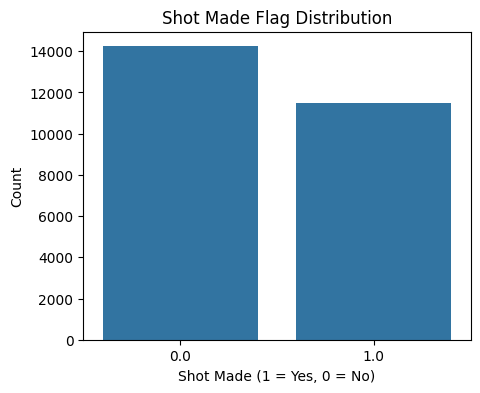

shot_made_flag
0.0    0.553839
1.0    0.446161
Name: proportion, dtype: float64


In [10]:
plt.figure(figsize=(5,4))
sns.countplot(x='shot_made_flag', data=nba)
plt.title("Shot Made Flag Distribution")
plt.xlabel("Shot Made (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

print(nba['shot_made_flag'].value_counts(normalize=True))

- The dataset is moderately imbalanced, with missed shots occurring more frequently than successful shots.

- Due to this imbalance, model evaluation must go beyond accuracy and focus on metrics like precision, recall, and F1-score to ensure reliable prediction of successful shots.

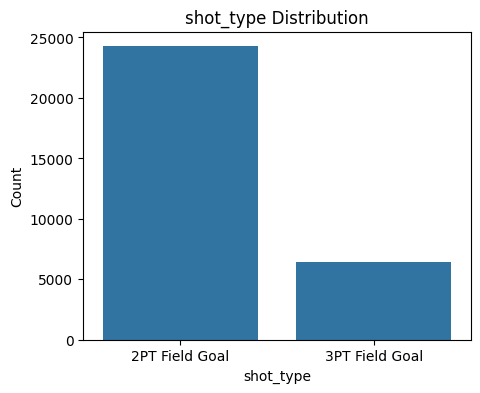

shot_type
2PT Field Goal    0.790664
3PT Field Goal    0.209336
Name: proportion, dtype: float64


In [11]:
plt.figure(figsize=(5,4))
sns.countplot(x='shot_type', data=nba)
plt.title("shot_type Distribution")
plt.xlabel("shot_type")
plt.ylabel("Count")
plt.show()

print(nba['shot_type'].value_counts(normalize=True))

- The majority of attempts are 2-point shots, while 3-point attempts occur relatively less frequently.
- This aligns with typical NBA gameplay trends, where players prioritize mid-range and close-range opportunities due to their higher scoring efficiency.

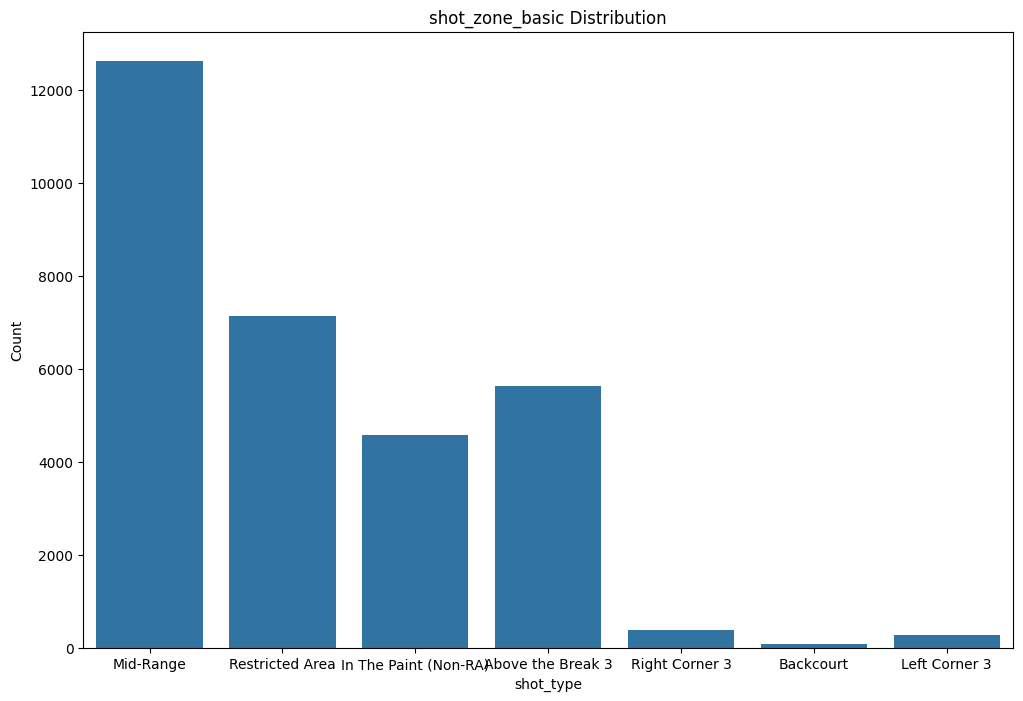

shot_zone_basic
Mid-Range                0.411278
Restricted Area          0.232466
Above the Break 3        0.183080
In The Paint (Non-RA)    0.149135
Right Corner 3           0.012607
Left Corner 3            0.009121
Backcourt                0.002313
Name: proportion, dtype: float64


In [12]:
plt.figure(figsize=(12,8))
sns.countplot(x='shot_zone_basic', data=nba)
plt.title("shot_zone_basic Distribution")
plt.xlabel("shot_type")
plt.ylabel("Count")
plt.show()

print(nba['shot_zone_basic'].value_counts(normalize=True))

- Most shots are attempted from the mid-range areas and the Restricted Area, indicating these are the most frequently used scoring zones.
- This highlights key player positioning trends on the court, showing that players tend to operate closer to the rim or within controlled shooting zones to maximize scoring opportunities.

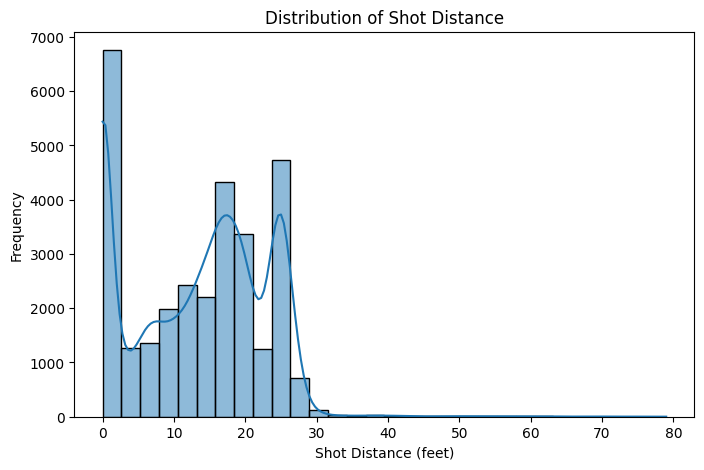

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(data=nba, x='shot_distance', kde=True, bins=30)
plt.title("Distribution of Shot Distance")
plt.xlabel("Shot Distance (feet)")
plt.ylabel("Frequency")
plt.show()

- Shot distance is right-skewed, indicating that players attempt significantly more short-range and mid-range shots compared to long-distance attempts.

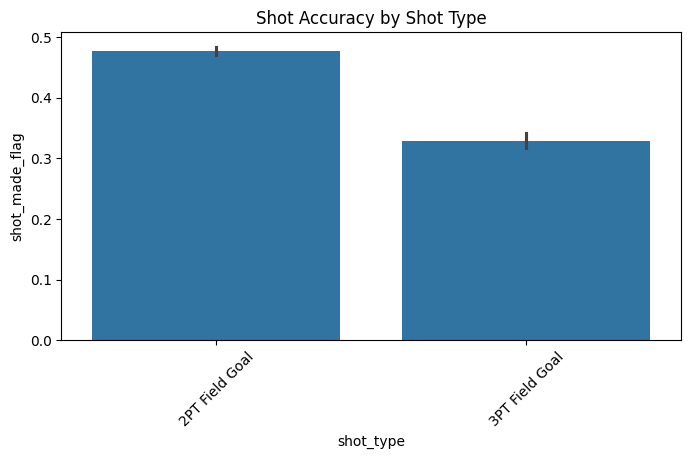

In [14]:
plt.figure(figsize=(8,4))
sns.barplot(x='shot_type', y='shot_made_flag', data=nba)
plt.title("Shot Accuracy by Shot Type")
plt.xticks(rotation=45)
plt.show()

- 2-point shots show a higher conversion rate compared to 3-point attempts.
- This is expected, as closer-range shots generally offer higher scoring efficiency due to better control, balance, and reduced defensive difficulty.

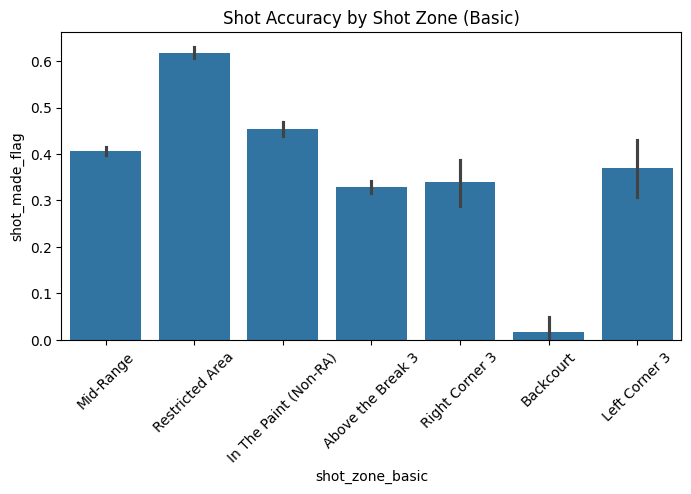

In [15]:
plt.figure(figsize=(8,4))
sns.barplot(x='shot_zone_basic', y='shot_made_flag', data=nba)
plt.title("Shot Accuracy by Shot Zone (Basic)")
plt.xticks(rotation=45)
plt.show()

- Close-range shot attempts demonstrate significantly higher accuracy compared to other areas on the court.
- In contrast, mid-range and perimeter shots generally exhibit lower conversion rates, reflecting the increased difficulty and defensive pressure at longer distances.

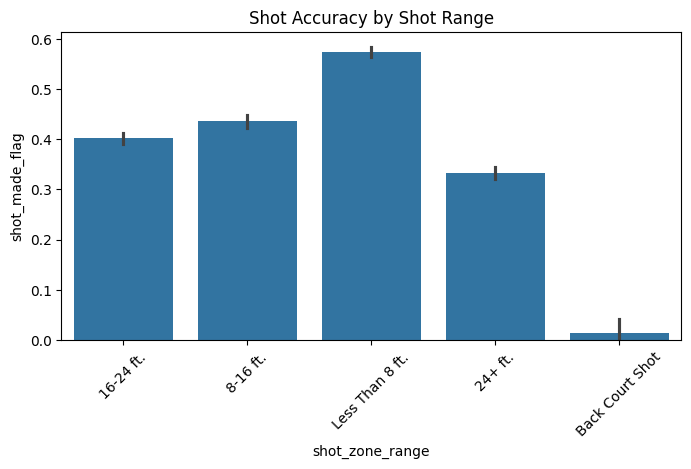

In [16]:
plt.figure(figsize=(8,4))
sns.barplot(x='shot_zone_range', y='shot_made_flag', data=nba)
plt.title("Shot Accuracy by Shot Range")
plt.xticks(rotation=45)
plt.show()

- Shot success consistently decreases as the distance increases, with conversion rates dropping from less than 8 feet to 24+ feet.

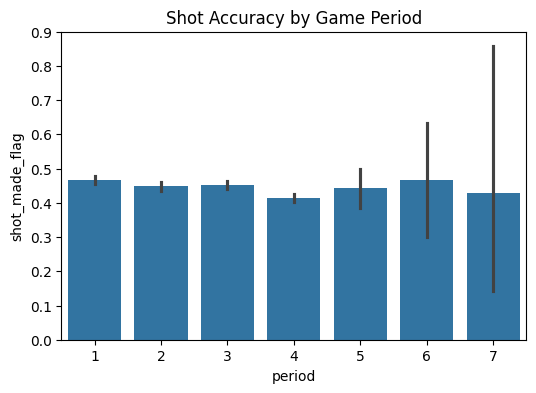

In [17]:
plt.figure(figsize=(6,4))
sns.barplot(x='period', y='shot_made_flag', data=nba)
plt.title("Shot Accuracy by Game Period")
plt.show()

- Shooting accuracy fluctuates slightly across different game periods.
- These minor variations may reflect changes in game intensity, defensive pressure, and player fatigue, although no strong or extreme performance pattern is observed across periods.

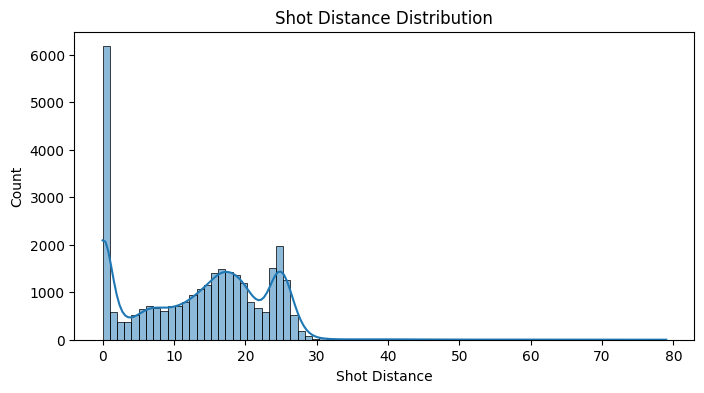

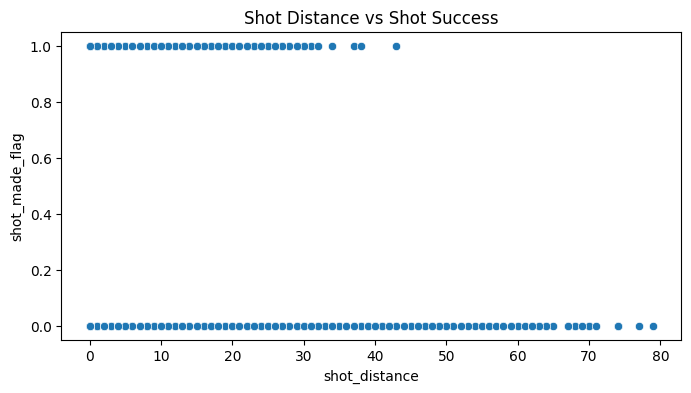

In [18]:
plt.figure(figsize=(8,4))
sns.histplot(nba['shot_distance'], kde=True)
plt.title("Shot Distance Distribution")
plt.xlabel("Shot Distance")
plt.show()

plt.figure(figsize=(8,4))
sns.scatterplot(x='shot_distance', y='shot_made_flag', data=nba)
plt.title("Shot Distance vs Shot Success")
plt.show()

- There is a clear trend indicating that shorter shot distances are associated with a significantly higher probability of success.
- In contrast, long-distance attempts generally exhibit lower accuracy, reflecting the increased difficulty and defensive challenge at greater ranges.

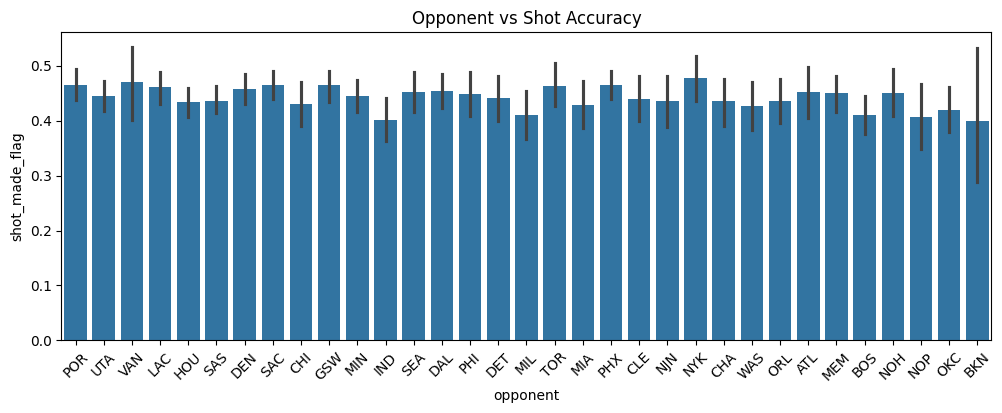

In [19]:
plt.figure(figsize=(12,4))
sns.barplot(x='opponent', y='shot_made_flag', data=nba)
plt.title("Opponent vs Shot Accuracy")
plt.xticks(rotation=45)
plt.show()

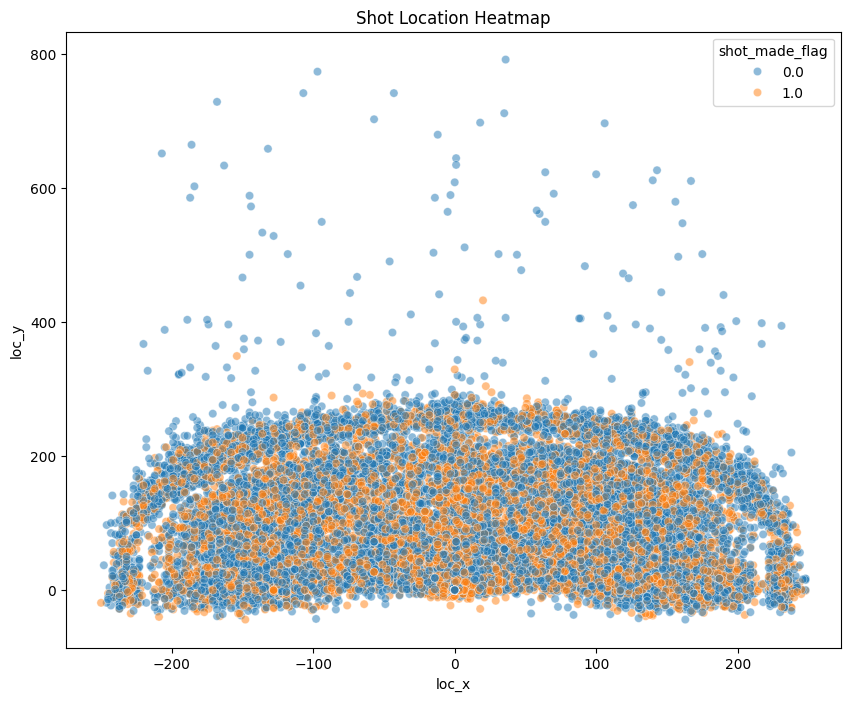

In [20]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=nba, x='loc_x', y='loc_y', hue='shot_made_flag', alpha=0.5)
plt.title("Shot Location Heatmap")
plt.show()

- Successful shots cluster around the basket area.
- Missed shots are more spread out, especially in long-range positions.
- This reflects standard NBA shooting dynamics.

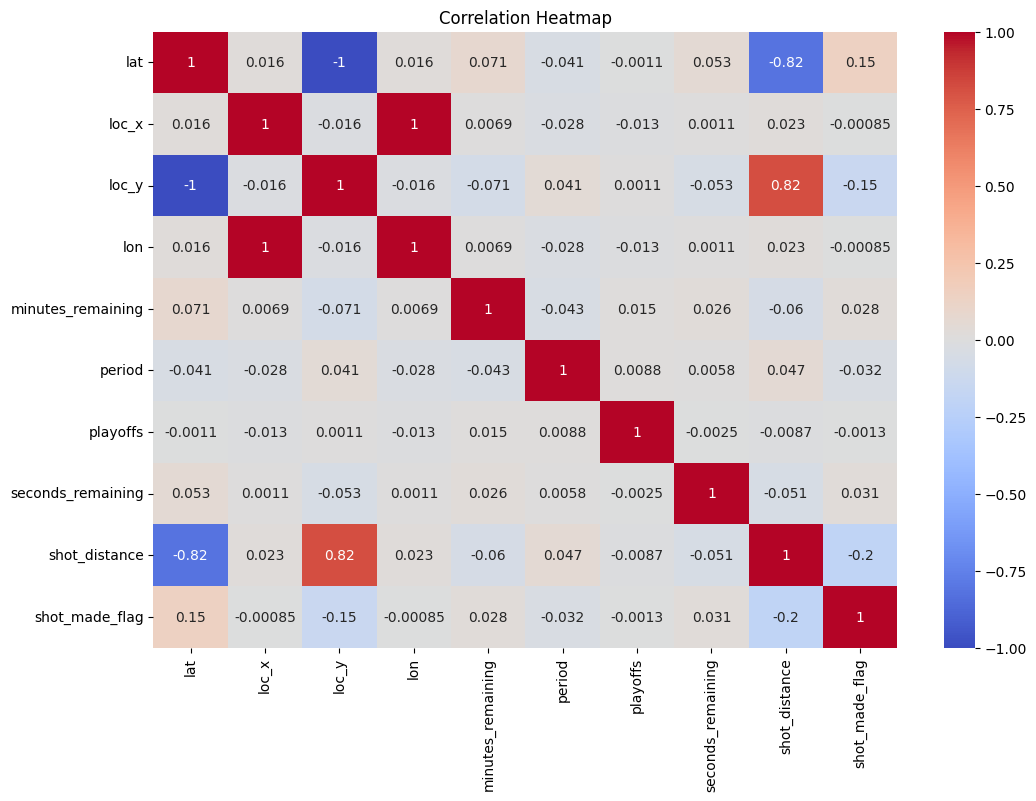

In [21]:
plt.figure(figsize=(12,8))
sns.heatmap(nba.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

- Shot distance has a strong negative correlation with shot success (–0.20), indicating that longer shots are less likely to be made.
lat and loc_y show a strong positive correlation (~0.82), while lat and shot_distance show a strong negative correlation (–0.82), confirming that court position strongly influences shot distance.
- Other features such as minutes_remaining, period, and playoffs have very weak correlations with the target, meaning they have minimal direct impact on predicting shot success.

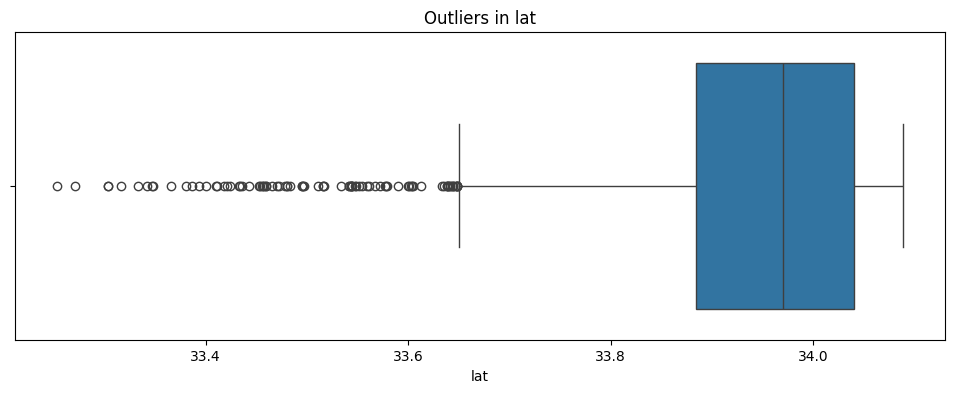

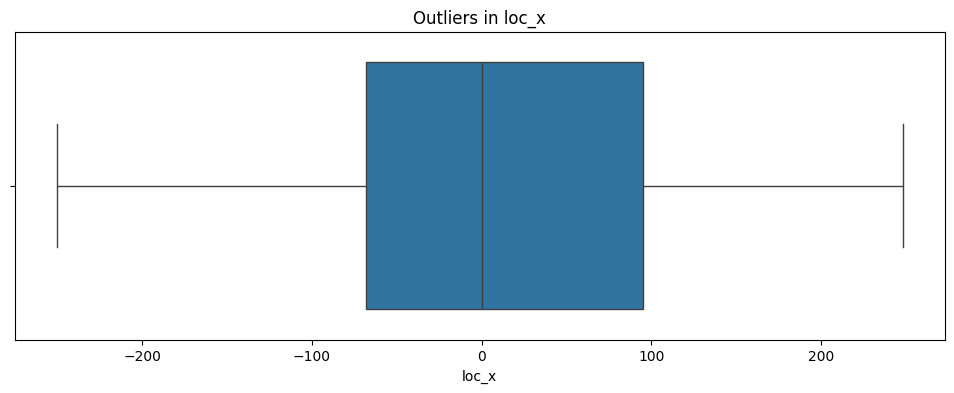

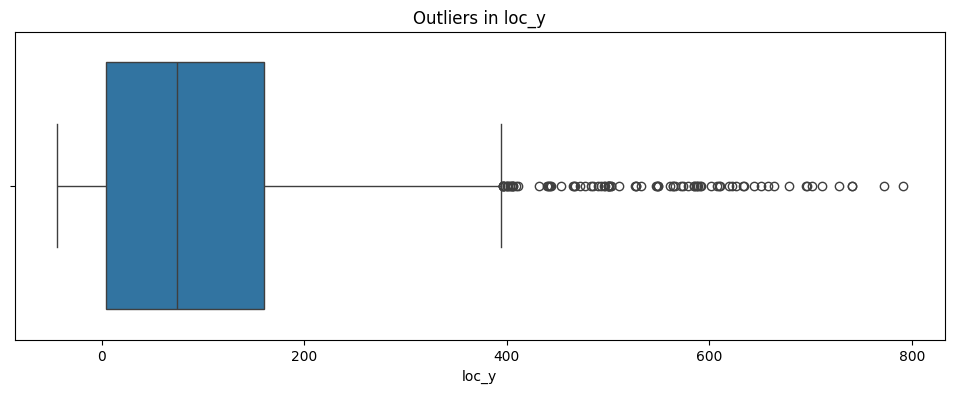

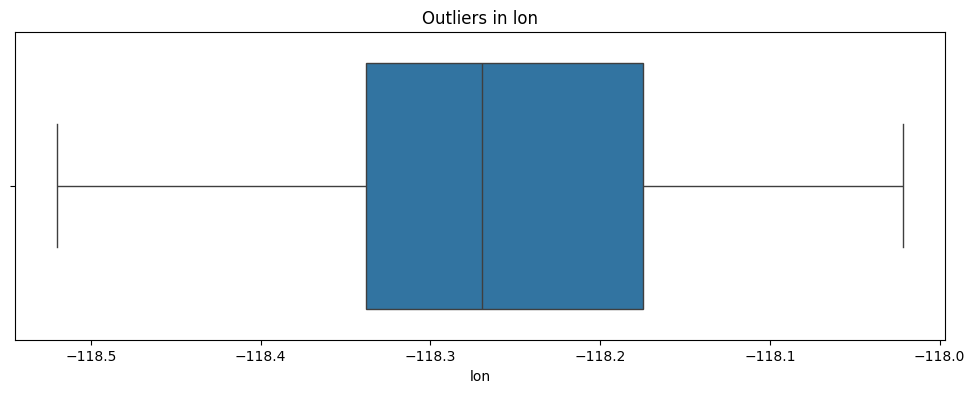

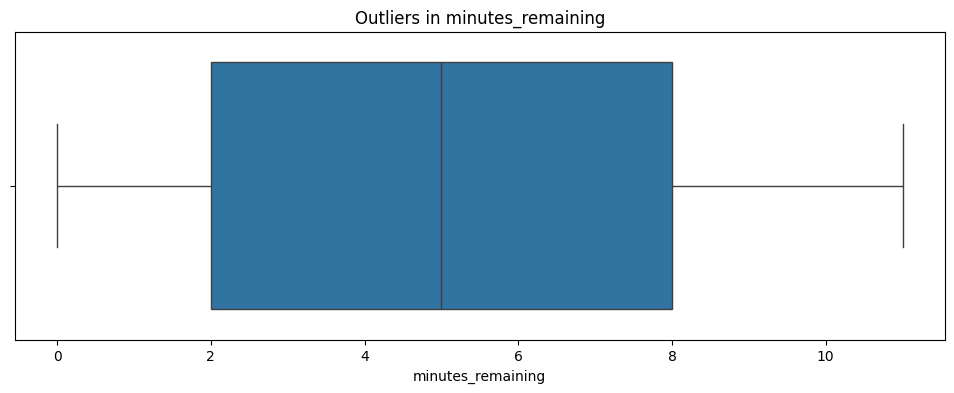

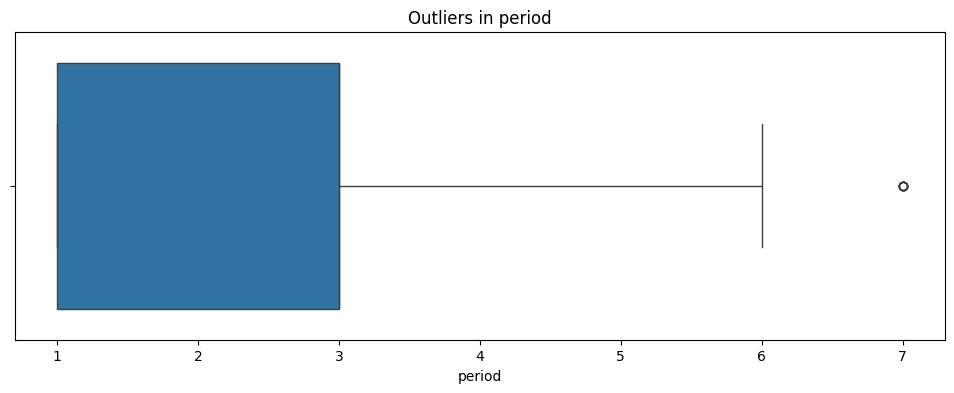

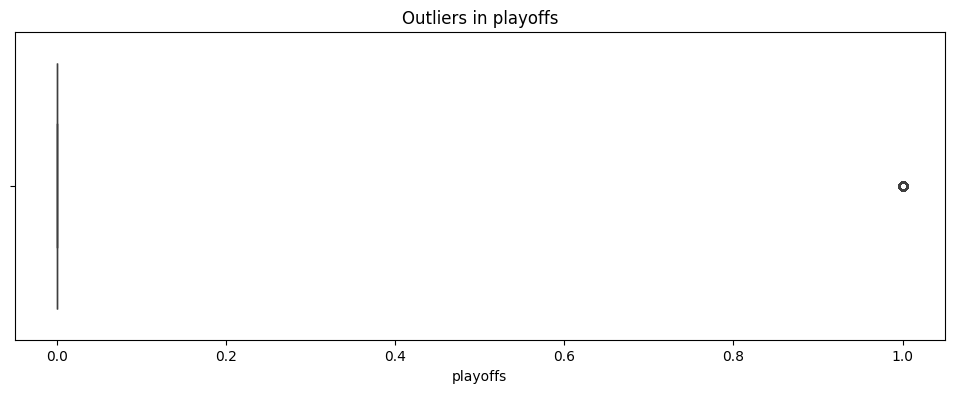

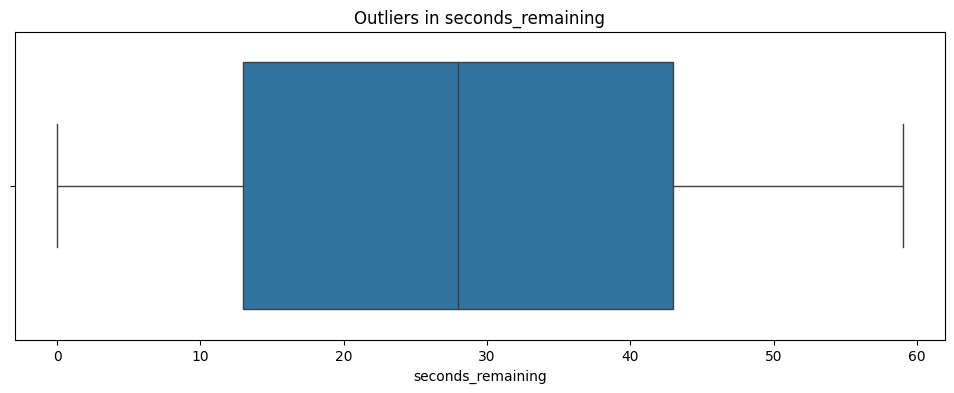

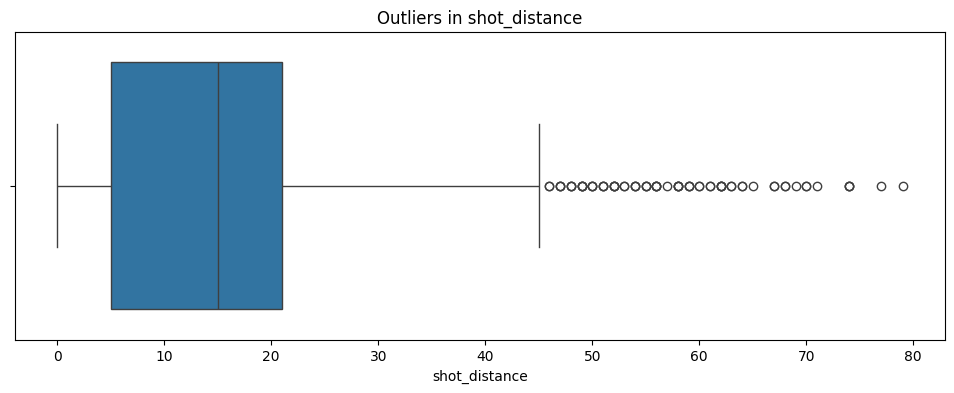

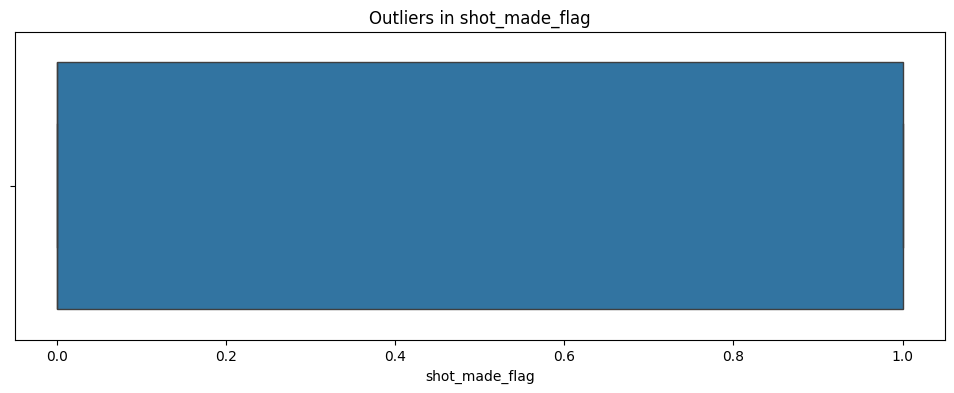

In [22]:
num_cols = nba.drop("shot_made_flag", axis=1)
num_cols = nba.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(12,4))
    sns.boxplot(x=nba[col])
    plt.title(f"Outliers in {col}")
    plt.show()

- Several features show outliers, they represent valid game situations (e.g., long-distance shots or extreme court positions). These values are important for modeling real basketball behavior, so no outlier removal is applied.
- Therefore, these outliers are intentionally retained, as removing them would distort the true distribution of on-court behavior and reduce the model’s ability to generalize to real gameplay scenarios.

### 4. Semi-Supervised Model

1. The target variable contained several missing values, which could not be simply dropped or imputed because the model requires valid labels to learn effectively. Removing them would reduce data availability and hurt model performance, so a semi-supervised learning strategy was applied.

2. The model was first trained on the labeled samples and then used to generate pseudo-labels for the unlabeled instances. These newly labeled samples were added back into the training dataset, allowing the final model to learn from both labeled and previously unlabeled data, improving overall robustness.

In [28]:
labeled_nba = nba[nba['shot_made_flag'].notnull()]
unlabeled_nba = nba[nba['shot_made_flag'].isnull()]
print(labeled_nba.shape)
print(unlabeled_nba.shape)

(25697, 20)
(5000, 20)


In [29]:
labeled_nba.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25697 entries, 1 to 30696
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   action_type         25697 non-null  object 
 1   combined_shot_type  25697 non-null  object 
 2   lat                 25697 non-null  float64
 3   loc_x               25697 non-null  int64  
 4   loc_y               25697 non-null  int64  
 5   lon                 25697 non-null  float64
 6   minutes_remaining   25697 non-null  int64  
 7   period              25697 non-null  int64  
 8   playoffs            25697 non-null  int64  
 9   season              25697 non-null  object 
 10  seconds_remaining   25697 non-null  int64  
 11  shot_distance       25697 non-null  int64  
 12  shot_made_flag      25697 non-null  float64
 13  shot_type           25697 non-null  object 
 14  shot_zone_area      25697 non-null  object 
 15  shot_zone_basic     25697 non-null  object 
 16  shot_zone

In [30]:
categorical_cols = labeled_nba.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = labeled_nba.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numeric_cols)

Categorical Columns: ['action_type', 'combined_shot_type', 'season', 'shot_type', 'shot_zone_area', 'shot_zone_basic', 'shot_zone_range', 'game_date', 'matchup', 'opponent']
Numerical Columns: ['lat', 'loc_x', 'loc_y', 'lon', 'minutes_remaining', 'period', 'playoffs', 'seconds_remaining', 'shot_distance', 'shot_made_flag']


In [34]:
labeled_X = pd.get_dummies(labeled_nba.drop(['lat', 'loc_x', 'loc_y', 'lon', 'minutes_remaining', 'period', 'playoffs', 'seconds_remaining', 'shot_distance', 'shot_made_flag'], axis=1), drop_first=True)
labeled_X.shape

(25697, 1756)

In [35]:
labeled_X_scaled = scaler.fit_transform(labeled_X)

In [36]:
unlabeled_X = pd.get_dummies(unlabeled_nba.drop(['lat', 'loc_x', 'loc_y', 'lon', 'minutes_remaining', 'period', 'playoffs', 'seconds_remaining', 'shot_distance', 'shot_made_flag'], axis=1), drop_first=True)
unlabeled_X = unlabeled_X.reindex(columns=labeled_X.columns, fill_value=0)
unlabeled_X_scaled = scaler.transform(unlabeled_X)

In [37]:
X_labeled = labeled_nba.drop('shot_made_flag', axis=1)
y_labeled = labeled_nba['shot_made_flag']

In [38]:
X_unlabeled = unlabeled_nba.drop('shot_made_flag', axis=1)

In [39]:
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.ensemble import RandomForestClassifier

base_model = RandomForestClassifier(n_estimators=200, random_state=42)

self_training_model = SelfTrainingClassifier(
    base_estimator=base_model,
    threshold=0.7,
    verbose=True
)

self_training_model.fit(labeled_X_scaled, y_labeled)


C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\semi_supervised\_self_training.py:210: FutureWarning: `base_estimator` has been deprecated in 1.6 and will be removed in 1.8. Please use `estimator` instead.
  warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\semi_supervised\_self_training.py:287: UserWarning: y contains no unlabeled samples
  warnings.warn("y contains no unlabeled samples", UserWarning)


,estimator,None
,base_estimator,RandomForestC...ndom_state=42)
,threshold,0.7
,criterion,'threshold'
,k_best,10
,max_iter,10
,verbose,True
,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [40]:
pseudo_labels = self_training_model.predict(unlabeled_X_scaled)

In [41]:
nba.loc[nba['shot_made_flag'].isnull(), 'shot_made_flag'] = pseudo_labels

In [42]:
final_nba = nba.copy()

In [43]:
final_nba.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30697 entries, 0 to 30696
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   action_type         30697 non-null  object 
 1   combined_shot_type  30697 non-null  object 
 2   lat                 30697 non-null  float64
 3   loc_x               30697 non-null  int64  
 4   loc_y               30697 non-null  int64  
 5   lon                 30697 non-null  float64
 6   minutes_remaining   30697 non-null  int64  
 7   period              30697 non-null  int64  
 8   playoffs            30697 non-null  int64  
 9   season              30697 non-null  object 
 10  seconds_remaining   30697 non-null  int64  
 11  shot_distance       30697 non-null  int64  
 12  shot_made_flag      30697 non-null  float64
 13  shot_type           30697 non-null  object 
 14  shot_zone_area      30697 non-null  object 
 15  shot_zone_basic     30697 non-null  object 
 16  shot

In [44]:
final_nba["shot_made_flag"].value_counts()

shot_made_flag
0.0    17271
1.0    13426
Name: count, dtype: int64

- Here, the original target variable’s null values have been replaced using the Semi-Supervised Model.

In [50]:
x = final_nba.drop("shot_made_flag", axis=1)
y = final_nba["shot_made_flag"]

In [46]:
final_nba.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30697 entries, 0 to 30696
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   action_type         30697 non-null  object 
 1   combined_shot_type  30697 non-null  object 
 2   lat                 30697 non-null  float64
 3   loc_x               30697 non-null  int64  
 4   loc_y               30697 non-null  int64  
 5   lon                 30697 non-null  float64
 6   minutes_remaining   30697 non-null  int64  
 7   period              30697 non-null  int64  
 8   playoffs            30697 non-null  int64  
 9   season              30697 non-null  object 
 10  seconds_remaining   30697 non-null  int64  
 11  shot_distance       30697 non-null  int64  
 12  shot_made_flag      30697 non-null  float64
 13  shot_type           30697 non-null  object 
 14  shot_zone_area      30697 non-null  object 
 15  shot_zone_basic     30697 non-null  object 
 16  shot

#### 5. Scaling and Feature Engineering

In [51]:
x = pd.get_dummies(x.drop(['lat', 'loc_x', 'loc_y', 'lon', 'minutes_remaining', 'period', 'playoffs', 'seconds_remaining', 'shot_distance'], axis=1), drop_first=True)
x.shape

(30697, 1759)

In [47]:
x = pd.get_dummies(x, drop_first=True)
x.shape

(30697, 1768)

In [52]:
x_scaling = scaler.fit_transform(x)
x_scaling

array([[-0.0511168 , -0.00570767, -0.01398203, ..., -0.22586537,
        -0.08988077, -0.14119328],
       [-0.0511168 , -0.00570767, -0.01398203, ..., -0.22586537,
        -0.08988077, -0.14119328],
       [-0.0511168 , -0.00570767, -0.01398203, ..., -0.22586537,
        -0.08988077, -0.14119328],
       ...,
       [-0.0511168 , -0.00570767, -0.01398203, ..., -0.22586537,
        -0.08988077, -0.14119328],
       [-0.0511168 , -0.00570767, -0.01398203, ..., -0.22586537,
        -0.08988077, -0.14119328],
       [-0.0511168 , -0.00570767, -0.01398203, ..., -0.22586537,
        -0.08988077, -0.14119328]], shape=(30697, 1759))

In [53]:
x_train1, x_test1, y_train1, y_test1 = train_test_split(x_scaling,y,test_size = 0.3, random_state = 42)
print("x_train1",x_train1.shape)
print("x_test1",x_test1.shape)
print("y_train1", y_train1.shape)
print("y_test1",y_test1.shape)

x_train1 (21487, 1759)
x_test1 (9210, 1759)
y_train1 (21487,)
y_test1 (9210,)


### 6. Model Development
Testing with Multiple Models for Better Prediction

#### Logistic Regression

In [54]:
lr=LogisticRegression()
lr.fit(x_train1,y_train1)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [55]:
y_pr = lr.predict(x_test1)
accuracy_score(y_test1,y_pr)

0.6729641693811075

In [56]:
y_pre = lr.predict(x_train1)
accuracy_score(y_train1,y_pre)

0.722529901801089

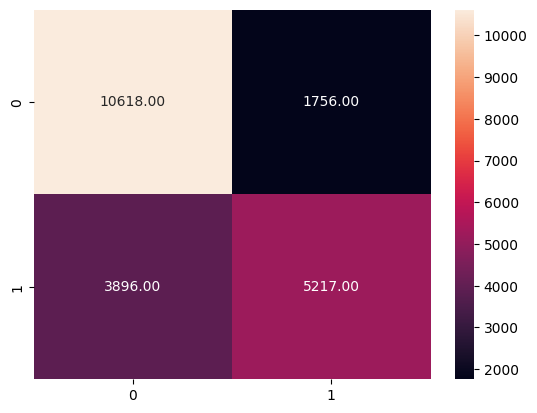

In [28]:
cm=sns.heatmap(confusion_matrix(y_train1,y_pre),annot = True,fmt='.2f');

In [58]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.3, random_state = 42)

#### Random Forest Classifier

#### Using GridSearchCV to understand better parameters

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],   
    'bootstrap': [True, False]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,          
    n_jobs=-1,         
    verbose=2,
    scoring='accuracy'       
)

grid.fit(x_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Fitting 3 folds for each of 432 candidates, totalling 1296 fits
Best Params: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best Score: 0.723553736519424


In [59]:
rfc = RandomForestClassifier(random_state=42, bootstrap= True, max_depth= None, max_features= 'sqrt',
min_samples_leaf= 1, min_samples_split= 5, n_estimators= 300)

rfc.fit(x_train,y_train)
y_predict = rfc.predict(x_test)
y_predic = rfc.predict(x_train)

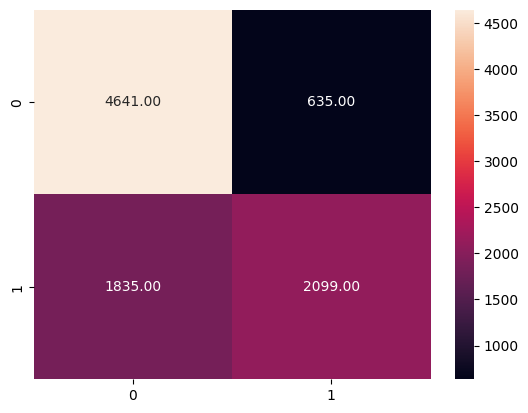

In [47]:
cm=sns.heatmap(confusion_matrix(y_test, y_predict),annot = True,fmt='.2f');

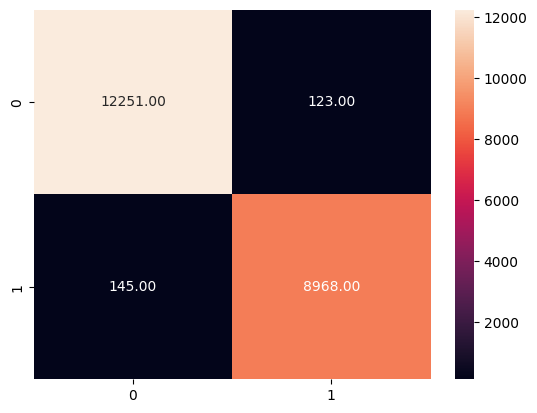

In [48]:
cm=sns.heatmap(confusion_matrix(y_train, y_predic),annot = True,fmt='.2f');

#### XGB Classifier

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

xgb = XGBClassifier(
    objective='binary:logistic',
    
    eval_metric='logloss',
    use_label_encoder=False
)

param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    'gamma': uniform(0, 5),
    'min_child_weight': randint(1, 10)
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,        
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(x_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)


In [60]:
from xgboost import XGBClassifier
best_model = XGBClassifier(
    colsample_bytree=0.8121770240668966,
    gamma=1.47816842918857,
    learning_rate=0.041648277949081186,
    max_depth=10,
    min_child_weight=8,
    n_estimators=385,
    subsample=0.9416401294594341,
    scale_pos_weight=17650/13047,
    random_state=42,
    objective='binary:logistic',
    eval_metric='logloss'
)

best_model.fit(x_train, y_train)

y_pred = best_model.predict(x_test)
y_predc = best_model.predict(x_train)

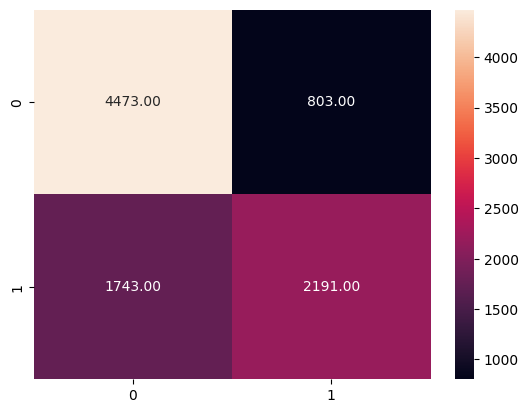

In [50]:
cm=sns.heatmap(confusion_matrix(y_test, y_pred),annot = True,fmt='.2f');

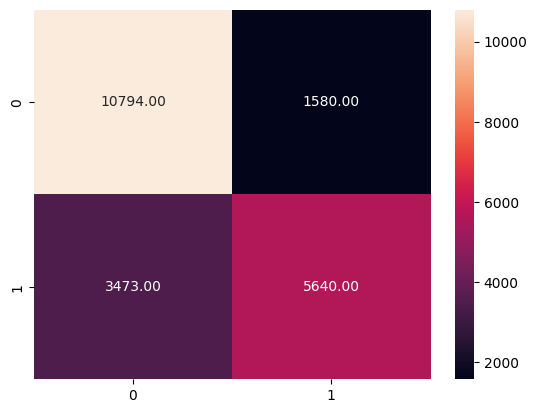

In [49]:
cm=sns.heatmap(confusion_matrix(y_train, y_predc),annot = True,fmt='.2f');

#### LightGBM Classifier

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

lgb = LGBMClassifier(
    objective='binary',
    random_state=42,
    n_jobs=-1
)

param_dist_lgb = {
    'n_estimators': randint(300, 1500),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.15),
    'num_leaves': randint(20, 150),
    'min_child_samples': randint(10, 80),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

lgb_search = RandomizedSearchCV(
    lgb,
    param_distributions=param_dist_lgb,
    n_iter=50,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

lgb_search.fit(x_train, y_train)

print("Best parameters for LightGBM:")
print(lgb_search.best_params_)

lgb_best = lgb_search.best_estimator_

lgb_preds = lgb_best.predict(x_test)
lgb_pred = lgb_best.predict(x_train)

Fitting 4 folds for each of 50 candidates, totalling 200 fits


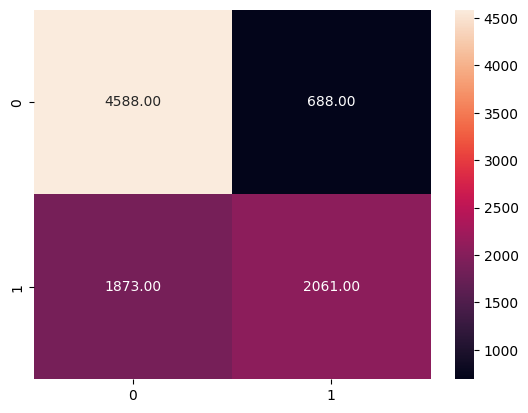

In [51]:
cm=sns.heatmap(confusion_matrix(y_test, lgb_preds),annot = True,fmt='.2f');

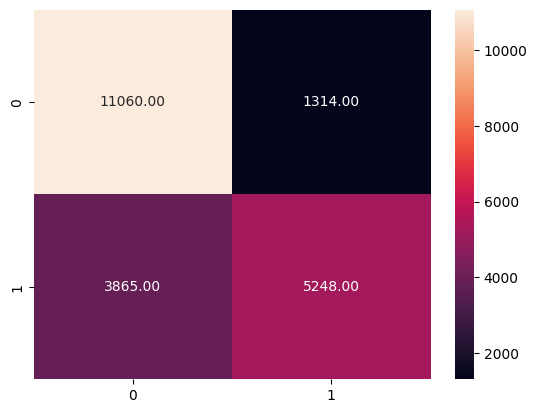

In [52]:
cm=sns.heatmap(confusion_matrix(y_train, lgb_pred),annot = True,fmt='.2f');

### Consolidated Evaluation Report

In [38]:

models = {
    "Logistic Regression": lr,
    "Random Forest": rfc,
    "XGBoost": best_model,
    "LightGBM": lgb_best
}

def get_predictions(model_name, model):

    if model_name == "Logistic Regression":
        train_pred = model.predict(x_train1)
        test_pred = model.predict(x_test1)
    else:
        train_pred = model.predict(x_train)
        test_pred = model.predict(x_test)

    return train_pred, test_pred


def evaluate_model(model_name, model):

    train_pred, test_pred = get_predictions(model_name, model)

    return {
        "Model": model_name,

        "Train Accuracy": accuracy_score(y_train if model_name!="Logistic Regression" else y_train1, train_pred),
        "Train Precision(1)": precision_score(y_train if model_name!="Logistic Regression" else y_train1, train_pred, pos_label=1),
        "Train Recall(1)": recall_score(y_train if model_name!="Logistic Regression" else y_train1, train_pred, pos_label=1),
        "Train F1(1)": f1_score(y_train if model_name!="Logistic Regression" else y_train1, train_pred, pos_label=1),

        "Test Accuracy": accuracy_score(y_test if model_name!="Logistic Regression" else y_test1, test_pred),
        "Test Precision(1)": precision_score(y_test if model_name!="Logistic Regression" else y_test1, test_pred, pos_label=1),
        "Test Recall(1)": recall_score(y_test if model_name!="Logistic Regression" else y_test1, test_pred, pos_label=1),
        "Test F1(1)": f1_score(y_test if model_name!="Logistic Regression" else y_test1, test_pred, pos_label=1),
    }


rows = [evaluate_model(name, model) for name, model in models.items()]
comparison_df = pd.DataFrame(rows).set_index("Model")

comparison_df.style.format("{:.4f}")


,Train Accuracy,Train Precision(1),Train Recall(1),Train F1(1),Test Accuracy,Test Precision(1),Test Recall(1),Test F1(1)
Model,,,,,,,,
Logistic Regression,0.7370,0.7482,0.5725,0.6486,0.6972,0.6893,0.5300,0.5992
Random Forest,0.9875,0.9865,0.9841,0.9853,0.7318,0.7677,0.5336,0.6296
XGBoost,0.7648,0.7812,0.6189,0.6906,0.7236,0.7318,0.5569,0.6325
LightGBM,0.7590,0.7998,0.5759,0.6696,0.7219,0.7497,0.5239,0.6168


### 7. Conlusion

1. The dataset contains several missing values in the target variable. Training a supervised model with missing labels would result in unreliable learning. To address this, a Semi-Supervised Learning approach was applied to generate pseudo-labels for the unlabeled rows, allowing the model to effectively utilize additional data instead of discarding it. However, achieving completely reliable learning still requires more real labeled samples in the future.

2. Since a considerable portion of the target values are pseudo-labeled, threshold tuning is not ideal for this model. Threshold adjustment relies on accurate ground-truth labels, and applying it on artificially generated labels may introduce bias and reduce reliability.

3. Among all the evaluated models, XGBoost delivered the best overall performance. Due to missing target values and class imbalance, relying solely on accuracy is misleading. Instead, Precision, Recall, and F1-Score provide a much clearer picture of model performance. XGBoost maintains a strong balance across these metrics, making it the most suitable model for this dataset.

4. Overall, this project demonstrates how semi-supervised learning can effectively handle missing target labels while still producing a reliable predictive model, providing meaningful insights into NBA shot success behavior.

### Business Impact

#### For Coaches

- Identify high-probability shooting zones

- Improve shot selection strategy

- Optimize player positioning

#### For Analysts

- Estimate expected shot success

- Compare player shot efficiency

- Identify risky shot patterns

#### For Teams

- Improve offensive efficiency

- Data-driven decision making

- Reduce low-probability attempts